# Simple Linear Regression for Emotion Recognition Using a YOLO Dataset

This notebook uses an existing **YOLO-format emotion dataset** with:

```text
dataset/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── test/
│   ├── images/
│   └── labels/
└── data.yaml
```

The notebook automatically reads class names and split paths from `data.yaml`.

## Concepts demonstrated

- YOLO annotation reading
- Bounding-box conversion
- Face/emotion-region cropping
- Grayscale + resize preprocessing
- One scalar image feature for true Simple Linear Regression
- One-vs-Rest SLR
- Slope \(b_1\)
- Intercept \(b_0\)
- Equation \(\hat y=b_0+b_1x\)
- Residuals
- SSE
- MSE
- \(R^2\)
- Validation accuracy
- Test accuracy
- Precision / Recall / F1-score
- Confusion matrix
- Visual prediction examples

> This is intentionally a teaching experiment. Facial-emotion classification is not naturally a regression problem, so SLR is used here to demonstrate regression concepts on an image dataset.

## Cell 1 — Install required packages

Run this once. After installation, restart the Jupyter kernel if necessary.

In [21]:
%pip install -q opencv-python-headless pyyaml numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Cell 2 — Import libraries

In [22]:
import os
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("OpenCV version:", cv2.__version__)
print("Libraries imported successfully.")

OpenCV version: 4.13.0
Libraries imported successfully.


## Cell 3 — Set your YOLO dataset path

Change only `DATASET_ROOT`.

Example:

```python
DATASET_ROOT = "/home/user/emotion_yolo_dataset"
```

In [23]:
# ============================================================
# CHANGE ONLY THIS PATH
# ============================================================

from pathlib import Path

DATASET_ROOT = r"/Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format"

DATASET_ROOT = Path(DATASET_ROOT)
YAML_PATH = DATASET_ROOT / "data.yaml"

print("Dataset root:", DATASET_ROOT)
print("YAML path   :", YAML_PATH)

if not YAML_PATH.exists():
    raise FileNotFoundError(
        f"Could not find data.yaml at: {YAML_PATH}\n"
        "Please correct DATASET_ROOT."
    )

Dataset root: /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format
YAML path   : /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/data.yaml


## Cell 4 — Read `data.yaml`

YOLO datasets often store paths such as:

```yaml
train: ../train/images
val: ../valid/images
test: ../test/images

names:
  0: Angry
  1: Happy
  2: Neutral
  3: Sad
  4: Surprise
```

This notebook reads them automatically.

In [24]:
import yaml

with open(YAML_PATH, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

print("YAML contents:")
print(data_yaml)

YAML contents:
{'data': '/kaggle/input/affectnet-yolo-format/YOLO_format', 'train': '/kaggle/input/affectnet-yolo-format/YOLO_format/train/images', 'val': '/kaggle/input/affectnet-yolo-format/YOLO_format/valid/images', 'test': '/kaggle/input/affectnet-yolo-format/YOLO_format/test/images', 'nc': 8, 'names': ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise'], 'network': 'yolov8n'}


In [25]:
# ============================================================
# CLASS NAMES
# ============================================================

names = data_yaml.get("names")

if names is None:
    raise KeyError("The YAML file does not contain a 'names' field.")

if isinstance(names, dict):
    # Handles integer or numeric-string keys
    sorted_items = sorted(names.items(), key=lambda kv: int(kv[0]))
    CLASS_NAMES = [str(v) for _, v in sorted_items]
else:
    CLASS_NAMES = [str(x) for x in names]

NUM_CLASSES = len(CLASS_NAMES)

print("\nEmotion classes:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i} -> {name}")

print("\nNumber of classes:", NUM_CLASSES)


Emotion classes:
0 -> Anger
1 -> Contempt
2 -> Disgust
3 -> Fear
4 -> Happy
5 -> Neutral
6 -> Sad
7 -> Surprise

Number of classes: 8


## Cell 5 — Resolve train / validation / test paths

The code first tries the paths in `data.yaml`.  
If they are not usable, it falls back to the common structure:

- `train/images`
- `valid/images`
- `test/images`

In [26]:
# ============================================================
# SET LOCAL DATASET PATHS
# ============================================================

TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
TRAIN_LABELS = DATASET_ROOT / "train" / "labels"

VALID_IMAGES = DATASET_ROOT / "valid" / "images"
VALID_LABELS = DATASET_ROOT / "valid" / "labels"

TEST_IMAGES = DATASET_ROOT / "test" / "images"
TEST_LABELS = DATASET_ROOT / "test" / "labels"

print("TRAIN images :", TRAIN_IMAGES)
print("TRAIN labels :", TRAIN_LABELS)
print("VALID images :", VALID_IMAGES)
print("VALID labels :", VALID_LABELS)
print("TEST images  :", TEST_IMAGES)
print("TEST labels  :", TEST_LABELS)

TRAIN images : /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/train/images
TRAIN labels : /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/train/labels
VALID images : /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/valid/images
VALID labels : /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/valid/labels
TEST images  : /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/test/images
TEST labels  : /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/test/labels


In [27]:
# ============================================================
# VERIFY PATHS
# ============================================================

all_paths = {
    "TRAIN_IMAGES": TRAIN_IMAGES,
    "TRAIN_LABELS": TRAIN_LABELS,
    "VALID_IMAGES": VALID_IMAGES,
    "VALID_LABELS": VALID_LABELS,
    "TEST_IMAGES": TEST_IMAGES,
    "TEST_LABELS": TEST_LABELS,
}

for name, path in all_paths.items():
    print(f"{name:15s} :", "[OK]" if Path(path).exists() else "[MISSING]", path)

TRAIN_IMAGES    : [OK] /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/train/images
TRAIN_LABELS    : [OK] /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/train/labels
VALID_IMAGES    : [OK] /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/valid/images
VALID_LABELS    : [OK] /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/valid/labels
TEST_IMAGES     : [OK] /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/test/images
TEST_LABELS     : [OK] /Users/pranathisingaluri/Downloads/emotion-system-main/YOLO_format/test/labels


## Cell 6 — YOLO bounding box conversion

A YOLO annotation line has:

```text
class_id  x_center  y_center  width  height
```

The coordinates are normalized from 0 to 1.

We convert them to pixel coordinates:

\[
(x_1,y_1,x_2,y_2)
\]

In [28]:
def yolo_to_bbox(x_center, y_center, width, height, img_width, img_height):
    xc = x_center * img_width
    yc = y_center * img_height
    bw = width * img_width
    bh = height * img_height

    x1 = int(round(xc - bw / 2))
    y1 = int(round(yc - bh / 2))
    x2 = int(round(xc + bw / 2))
    y2 = int(round(yc + bh / 2))

    x1 = max(0, min(x1, img_width - 1))
    y1 = max(0, min(y1, img_height - 1))
    x2 = max(1, min(x2, img_width))
    y2 = max(1, min(y2, img_height))

    return x1, y1, x2, y2

## Cell 7 — Preprocess each cropped face

Each annotated region is:

1. cropped using the YOLO bounding box,
2. converted to grayscale,
3. resized to \(100\times100\).

In [29]:
IMG_SIZE = 100

def preprocess_crop(crop):
    if crop is None or crop.size == 0:
        return None

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))

    return gray

## Cell 8 — Extract ONE feature

To remain **Simple Linear Regression**, the model must receive exactly **one predictor**.

Here we use the standard deviation of pixel intensity in the lower-central facial area:

\[
X = \sigma(\text{lower facial region})
\]

This is a deliberately simple classroom feature.

In [30]:
def extract_single_feature(face_gray):
    # lower-central region of normalized face crop
    region = face_gray[55:90, 20:80]

    feature = float(np.std(region))

    return feature

## Cell 9 — YOLO split loader

Each YOLO bounding box is treated as one emotion sample.

In [31]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def load_yolo_split(images_dir, labels_dir, split_name="split"):

    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)

    if not images_dir.exists():
        raise FileNotFoundError(f"{split_name} images folder not found: {images_dir}")

    if not labels_dir.exists():
        raise FileNotFoundError(f"{split_name} labels folder not found: {labels_dir}")

    image_files = sorted(
        p for p in images_dir.iterdir()
        if p.suffix.lower() in VALID_EXTENSIONS
    )

    features = []
    labels = []
    image_paths = []
    bounding_boxes = []

    skipped_no_label = 0
    skipped_bad_image = 0
    skipped_bad_box = 0

    for image_path in image_files:

        label_path = labels_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            skipped_no_label += 1
            continue

        image = cv2.imread(str(image_path))

        if image is None:
            skipped_bad_image += 1
            continue

        img_height, img_width = image.shape[:2]

        with open(label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) < 5:
                continue

            try:
                class_id = int(float(parts[0]))
                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])
            except ValueError:
                continue

            if not (0 <= class_id < NUM_CLASSES):
                continue

            x1, y1, x2, y2 = yolo_to_bbox(
                x_center,
                y_center,
                box_width,
                box_height,
                img_width,
                img_height
            )

            if x2 <= x1 or y2 <= y1:
                skipped_bad_box += 1
                continue

            crop = image[y1:y2, x1:x2]
            face_gray = preprocess_crop(crop)

            if face_gray is None:
                skipped_bad_box += 1
                continue

            feature = extract_single_feature(face_gray)

            features.append(feature)
            labels.append(class_id)
            image_paths.append(str(image_path))
            bounding_boxes.append((x1, y1, x2, y2))

    X = np.asarray(features, dtype=np.float64).reshape(-1, 1)
    y = np.asarray(labels, dtype=np.int64)

    print(f"{split_name.upper()}:")
    print("  image files     :", len(image_files))
    print("  emotion samples :", len(X))
    print("  X shape         :", X.shape)
    print("  y shape         :", y.shape)
    print("  missing labels  :", skipped_no_label)
    print("  unreadable imgs :", skipped_bad_image)
    print("  invalid boxes   :", skipped_bad_box)

    return X, y, image_paths, bounding_boxes

 Cell 10 — Load train, validation and test sets

In [32]:
X_train, y_train, train_paths, train_boxes = load_yolo_split(
    TRAIN_IMAGES,
    TRAIN_LABELS,
    "train"
)

print()

X_valid, y_valid, valid_paths, valid_boxes = load_yolo_split(
    VALID_IMAGES,
    VALID_LABELS,
    "validation"
)

print()

X_test, y_test, test_paths, test_boxes = load_yolo_split(
    TEST_IMAGES,
    TEST_LABELS,
    "test"
)

TRAIN:
  image files     : 17101
  emotion samples : 17101
  X shape         : (17101, 1)
  y shape         : (17101,)
  missing labels  : 0
  unreadable imgs : 0
  invalid boxes   : 0

VALIDATION:
  image files     : 5406
  emotion samples : 5406
  X shape         : (5406, 1)
  y shape         : (5406,)
  missing labels  : 0
  unreadable imgs : 0
  invalid boxes   : 0

TEST:
  image files     : 2755
  emotion samples : 2755
  X shape         : (2755, 1)
  y shape         : (2755,)
  missing labels  : 0
  unreadable imgs : 0
  invalid boxes   : 0


In [33]:
# Basic safety checks

if len(X_train) == 0:
    raise RuntimeError("No training samples were loaded.")

if len(X_valid) == 0:
    print("WARNING: No validation samples were loaded.")

if len(X_test) == 0:
    print("WARNING: No test samples were loaded.")

print("\nImportant:")
print("X_train has", X_train.shape[1], "feature column.")
print("Therefore this is Simple Linear Regression.")


Important:
X_train has 1 feature column.
Therefore this is Simple Linear Regression.


## Cell 11 — Class distribution

In [34]:
def class_distribution(y, split_name):
    rows = []

    for class_id, class_name in enumerate(CLASS_NAMES):
        count = int(np.sum(y == class_id))
        rows.append({
            "Class_ID": class_id,
            "Emotion": class_name,
            "Count": count
        })

    result = pd.DataFrame(rows)
    print(split_name)
    display(result)

    return result


train_distribution = class_distribution(y_train, "TRAIN")
valid_distribution = class_distribution(y_valid, "VALIDATION")
test_distribution = class_distribution(y_test, "TEST")

TRAIN


,Class_ID,Emotion,Count
0,0,Anger,2339
1,1,Contempt,1996
2,2,Disgust,2242
3,3,Fear,2021
4,4,Happy,2154
5,5,Neutral,1616
6,6,Sad,1914
7,7,Surprise,2819


VALIDATION


,Class_ID,Emotion,Count
0,0,Anger,712
1,1,Contempt,618
2,2,Disgust,672
3,3,Fear,622
4,4,Happy,791
5,5,Neutral,514
6,6,Sad,603
7,7,Surprise,874


TEST


,Class_ID,Emotion,Count
0,0,Anger,383
1,1,Contempt,332
2,2,Disgust,327
3,3,Fear,318
4,4,Happy,399
5,5,Neutral,250
6,6,Sad,278
7,7,Surprise,468


## Cell 12 — Visualize annotated crops

Always inspect a few samples before training.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


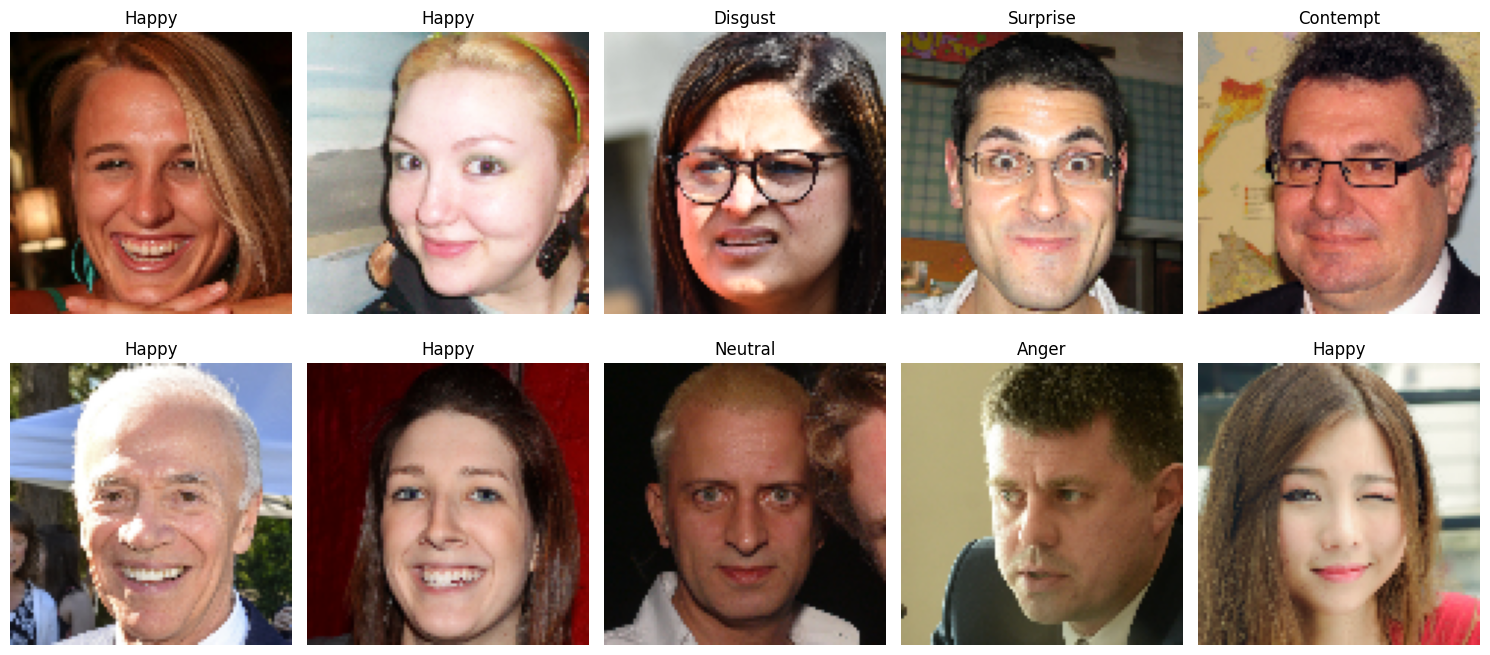

In [35]:
def show_samples(image_paths, boxes, labels, number=10):
    number = min(number, len(image_paths))

    if number == 0:
        print("No samples available.")
        return

    cols = 5
    rows = int(np.ceil(number / cols))

    plt.figure(figsize=(15, 3.5 * rows))

    for i in range(number):
        image = cv2.imread(image_paths[i])

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        x1, y1, x2, y2 = boxes[i]
        crop = image[y1:y2, x1:x2]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(crop)
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(train_paths, train_boxes, y_train, number=10)

## Cell 13 — View the numerical training data

In [36]:
train_df = pd.DataFrame({
    "Image": train_paths,
    "Feature_X": X_train.flatten(),
    "Class_ID": y_train,
    "Emotion": [CLASS_NAMES[i] for i in y_train]
})

display(train_df.head(20))

,Image,Feature_X,Class_ID,Emotion
0,/Users/pranathisingaluri/Downloads/emotion-sys...,41.049838,4,Happy
1,/Users/pranathisingaluri/Downloads/emotion-sys...,56.673730,4,Happy
2,/Users/pranathisingaluri/Downloads/emotion-sys...,59.022977,2,Disgust
3,/Users/pranathisingaluri/Downloads/emotion-sys...,54.205797,7,Surprise
4,/Users/pranathisingaluri/Downloads/emotion-sys...,26.857948,1,Contempt
5,/Users/pranathisingaluri/Downloads/emotion-sys...,46.592386,4,Happy
6,/Users/pranathisingaluri/Downloads/emotion-sys...,53.939593,4,Happy
7,/Users/pranathisingaluri/Downloads/emotion-sys...,34.520885,5,Neutral
8,/Users/pranathisingaluri/Downloads/emotion-sys...,46.992610,0,Anger
9,/Users/pranathisingaluri/Downloads/emotion-sys...,53.583093,4,Happy


## Cell 14 — Feature distribution

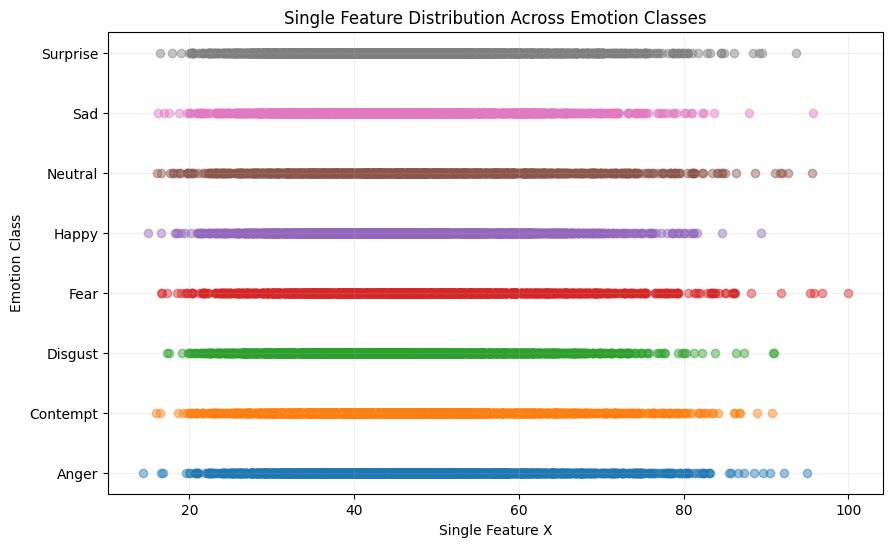

In [37]:
plt.figure(figsize=(10, 6))

for class_id, class_name in enumerate(CLASS_NAMES):

    values = X_train[y_train == class_id].flatten()

    y_vis = np.full(len(values), class_id)

    plt.scatter(
        values,
        y_vis,
        alpha=0.45,
        label=class_name
    )

plt.xlabel("Single Feature X")
plt.ylabel("Emotion Class")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.title("Single Feature Distribution Across Emotion Classes")
plt.grid(alpha=0.2)
plt.show()

# Simple Linear Regression Training

For each emotion we create one binary target:

\[
y=
\begin{cases}
1 & \text{target emotion}\\
0 & \text{all other emotions}
\end{cases}
\]

Each emotion model learns:

\[
\hat y=b_0+b_1x
\]

In [38]:
# ============================================================
# TRAIN ONE SLR MODEL PER EMOTION
# ============================================================

models = {}
training_results = []

for class_id, class_name in enumerate(CLASS_NAMES):

    print("\n" + "=" * 72)
    print(f"{class_name.upper()} vs REST")
    print("=" * 72)

    y_train_binary = (y_train == class_id).astype(int)

    model = LinearRegression()
    model.fit(X_train, y_train_binary)

    models[class_id] = model

    y_pred_train = model.predict(X_train)

    b0 = float(model.intercept_)
    b1 = float(model.coef_[0])

    residuals = y_train_binary - y_pred_train

    sse = float(np.sum(residuals ** 2))
    mse = float(mean_squared_error(y_train_binary, y_pred_train))
    r2 = float(r2_score(y_train_binary, y_pred_train))

    print(f"Intercept b0 : {b0:.6f}")
    print(f"Slope b1     : {b1:.6f}")
    print(f"Equation     : y_hat = {b0:.6f} + ({b1:.6f})x")
    print(f"SSE          : {sse:.6f}")
    print(f"MSE          : {mse:.6f}")
    print(f"R^2          : {r2:.6f}")

    training_results.append({
        "Class_ID": class_id,
        "Emotion": class_name,
        "Intercept_b0": b0,
        "Slope_b1": b1,
        "SSE": sse,
        "MSE": mse,
        "R2": r2
    })


ANGER vs REST
Intercept b0 : 0.100015
Slope b1     : 0.000796
Equation     : y_hat = 0.100015 + (0.000796)x
SSE          : 2017.411277
MSE          : 0.117970
R^2          : 0.000827

CONTEMPT vs REST
Intercept b0 : 0.105278
Slope b1     : 0.000248
Equation     : y_hat = 0.105278 + (0.000248)x
SSE          : 1762.868436
MSE          : 0.103086
R^2          : 0.000092

DISGUST vs REST
Intercept b0 : 0.185447
Slope b1     : -0.001177
Equation     : y_hat = 0.185447 + (-0.001177)x
SSE          : 1944.415345
MSE          : 0.113702
R^2          : 0.001874

FEAR vs REST
Intercept b0 : 0.070097
Slope b1     : 0.001042
Equation     : y_hat = 0.070097 + (0.001042)x
SSE          : 1779.299762
MSE          : 0.104047
R^2          : 0.001604

HAPPY vs REST
Intercept b0 : 0.145682
Slope b1     : -0.000427
Equation     : y_hat = 0.145682 + (-0.000427)x
SSE          : 1882.206525
MSE          : 0.110064
R^2          : 0.000255

NEUTRAL vs REST
Intercept b0 : 0.063559
Slope b1     : 0.000670
Equatio

## Cell 16 — Regression summary

In [39]:
results_df = pd.DataFrame(training_results)
display(results_df)

,Class_ID,Emotion,Intercept_b0,Slope_b1,SSE,MSE,R2
0,0,Anger,0.100015,0.000796,2017.411277,0.117970,0.000827
1,1,Contempt,0.105278,0.000248,1762.868436,0.103086,0.000092
2,2,Disgust,0.185447,-0.001177,1944.415345,0.113702,0.001874
3,3,Fear,0.070097,0.001042,1779.299762,0.104047,0.001604
4,4,Happy,0.145682,-0.000427,1882.206525,0.110064,0.000255
5,5,Neutral,0.063559,0.000670,1462.108993,0.085498,0.000809
6,6,Sad,0.143793,-0.000690,1698.523288,0.099323,0.000739
7,7,Surprise,0.186129,-0.000461,2353.744268,0.137638,0.000238


## Cell 17 — Print all learned equations

In [40]:
for class_id, class_name in enumerate(CLASS_NAMES):
    model = models[class_id]
    b0 = model.intercept_
    b1 = model.coef_[0]

    print(
        f"{class_name:15s}: "
        f"y_hat = {b0:.6f} + ({b1:.6f})x"
    )

Anger          : y_hat = 0.100015 + (0.000796)x
Contempt       : y_hat = 0.105278 + (0.000248)x
Disgust        : y_hat = 0.185447 + (-0.001177)x
Fear           : y_hat = 0.070097 + (0.001042)x
Happy          : y_hat = 0.145682 + (-0.000427)x
Neutral        : y_hat = 0.063559 + (0.000670)x
Sad            : y_hat = 0.143793 + (-0.000690)x
Surprise       : y_hat = 0.186129 + (-0.000461)x


## Cell 18 — Regression-line plots

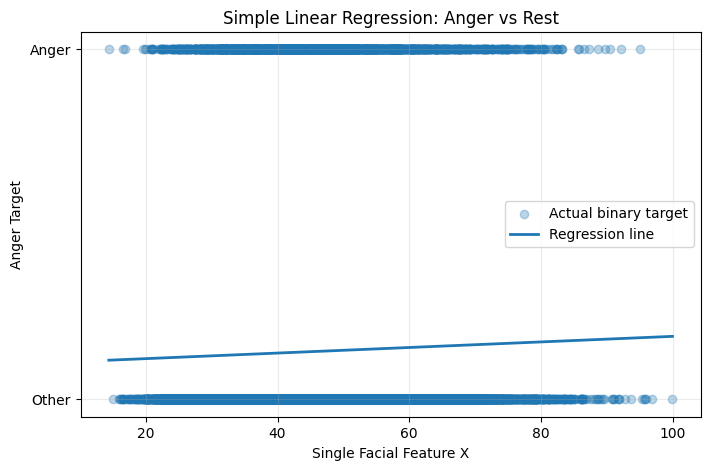

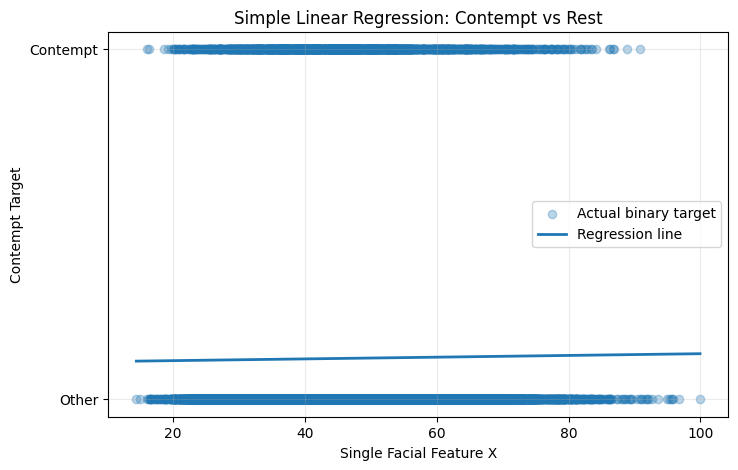

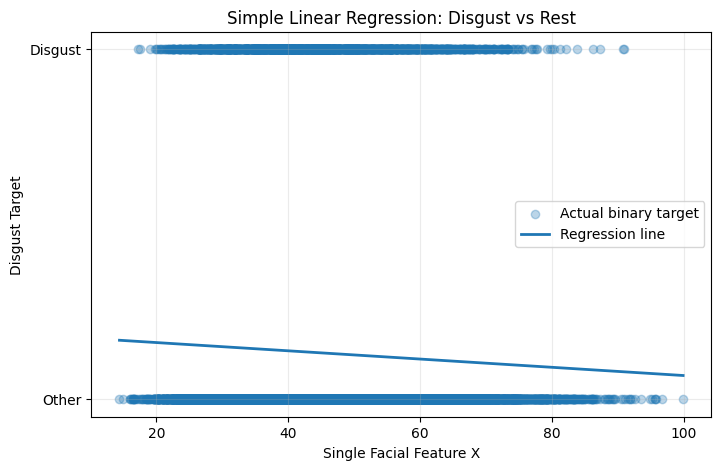

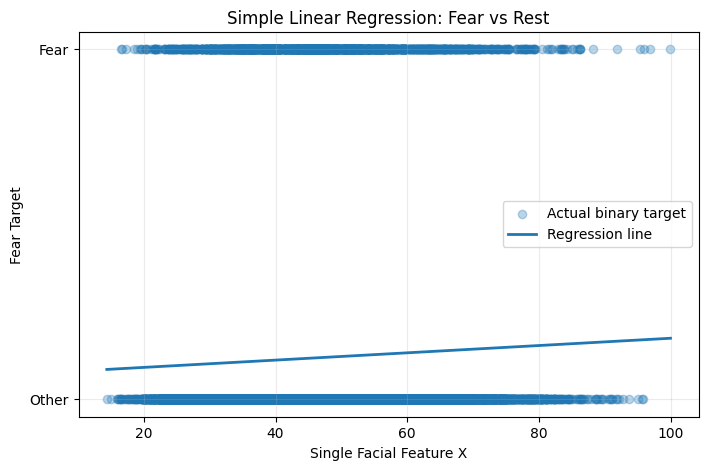

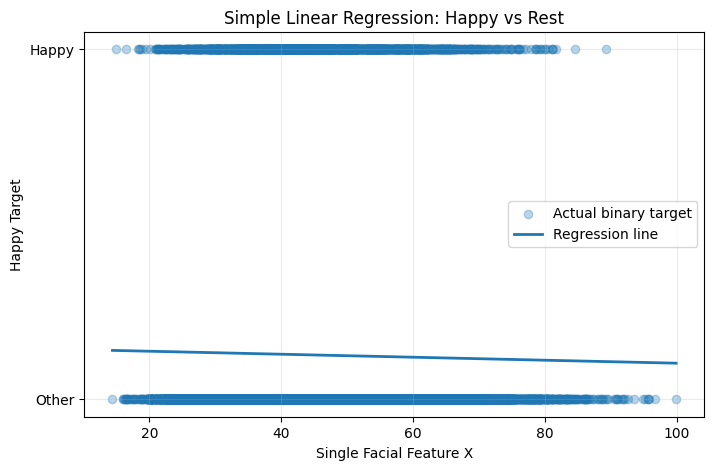

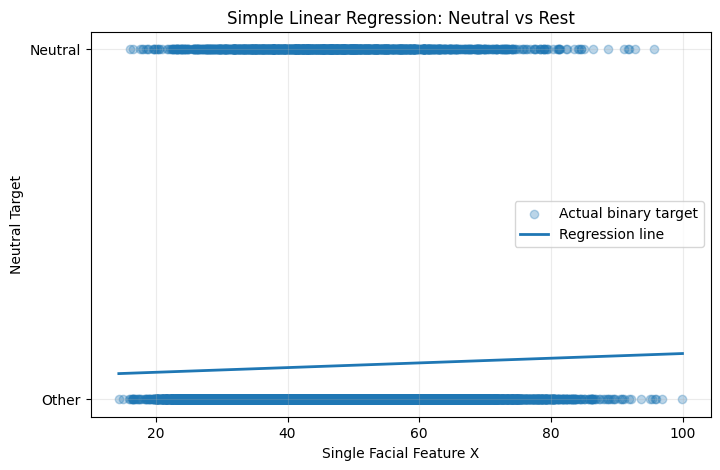

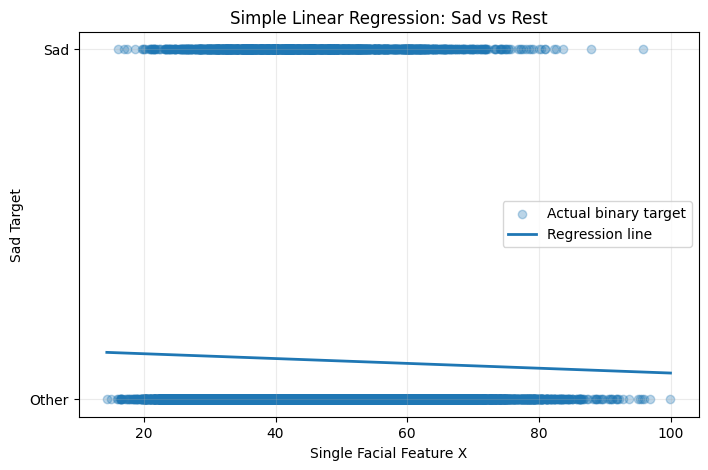

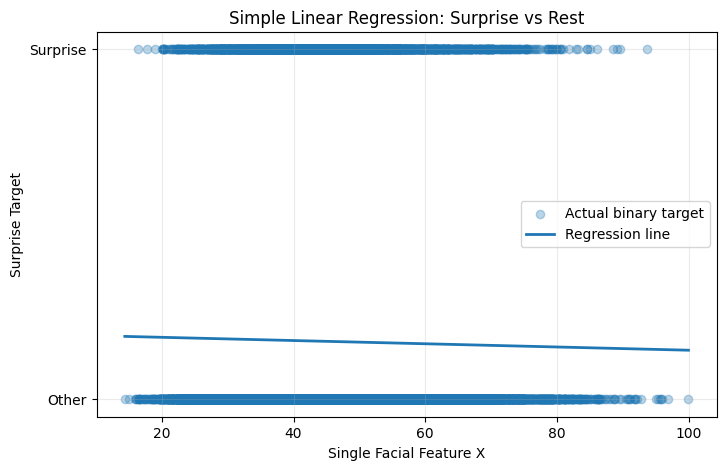

In [41]:
X_line = np.linspace(
    float(X_train.min()),
    float(X_train.max()),
    200
).reshape(-1, 1)

for class_id, class_name in enumerate(CLASS_NAMES):

    y_train_binary = (y_train == class_id).astype(int)

    model = models[class_id]
    y_line = model.predict(X_line)

    plt.figure(figsize=(8, 5))

    plt.scatter(
        X_train[:, 0],
        y_train_binary,
        alpha=0.30,
        label="Actual binary target"
    )

    plt.plot(
        X_line[:, 0],
        y_line,
        linewidth=2,
        label="Regression line"
    )

    plt.xlabel("Single Facial Feature X")
    plt.ylabel(f"{class_name} Target")
    plt.yticks([0, 1], ["Other", class_name])
    plt.title(f"Simple Linear Regression: {class_name} vs Rest")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

## Cell 19 — Residual, SSE and MSE

Residual:

\[
e_i=y_i-\hat y_i
\]

SSE:

\[
SSE=\sum_i(y_i-\hat y_i)^2
\]

MSE:

\[
MSE=\frac{1}{N}\sum_i(y_i-\hat y_i)^2
\]

In [42]:
# Choose the first emotion as an example
example_class_id = 0
example_class_name = CLASS_NAMES[example_class_id]

if len(X_valid) > 0:

    model = models[example_class_id]

    y_actual = (y_valid == example_class_id).astype(int)
    y_predicted = model.predict(X_valid)

    residuals = y_actual - y_predicted

    residual_df = pd.DataFrame({
        "X": X_valid.flatten(),
        "Actual_y": y_actual,
        "Predicted_y_hat": y_predicted,
        "Residual": residuals
    })

    display(residual_df.head(20))

    SSE_manual = np.sum((y_actual - y_predicted) ** 2)
    MSE_manual = np.mean((y_actual - y_predicted) ** 2)

    print("Example emotion:", example_class_name)
    print("Manual SSE:", SSE_manual)
    print("Manual MSE:", MSE_manual)

else:
    print("Validation split is empty.")

,X,Actual_y,Predicted_y_hat,Residual
0,59.849595,0,0.147681,-0.147681
1,44.469550,0,0.135432,-0.135432
2,38.818637,0,0.130931,-0.130931
3,45.350208,0,0.136133,-0.136133
4,48.104883,0,0.138327,-0.138327
5,47.548871,0,0.137884,-0.137884
6,69.473510,0,0.155346,-0.155346
7,37.384317,0,0.129789,-0.129789
8,38.173959,0,0.130418,-0.130418
9,56.980128,0,0.145396,-0.145396


Example emotion: Anger
Manual SSE: 617.6289030721186
Manual MSE: 0.11424877970257466


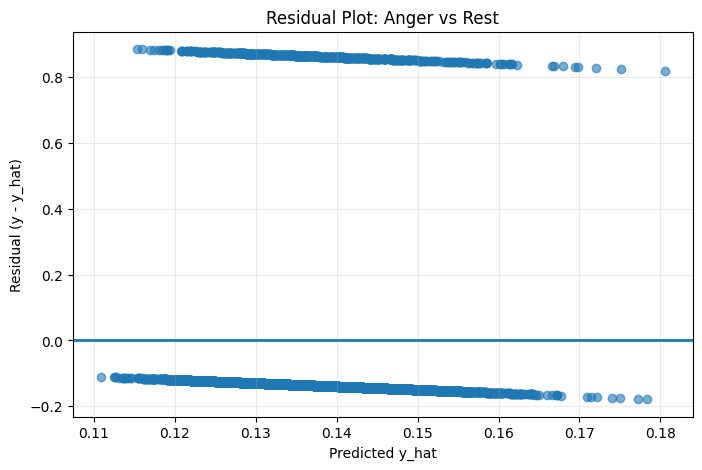

In [43]:
# Residual plot

if len(X_valid) > 0:

    plt.figure(figsize=(8, 5))

    plt.scatter(y_predicted, residuals, alpha=0.6)
    plt.axhline(0, linewidth=2)

    plt.xlabel("Predicted y_hat")
    plt.ylabel("Residual (y - y_hat)")
    plt.title(f"Residual Plot: {example_class_name} vs Rest")
    plt.grid(alpha=0.25)
    plt.show()

# Multi-Class Emotion Prediction

Each SLR model gives a regression score:

\[
s_k=b_{0,k}+b_{1,k}x
\]

The predicted emotion is:

\[
\hat c=\arg\max_k s_k
\]

These are regression scores, **not probabilities**.

In [44]:
def predict_emotion(feature_value):

    X_input = np.array([[feature_value]], dtype=np.float64)

    scores = {}

    for class_id, class_name in enumerate(CLASS_NAMES):
        score = models[class_id].predict(X_input)[0]
        scores[class_id] = float(score)

    predicted_id = max(scores, key=scores.get)
    predicted_name = CLASS_NAMES[predicted_id]

    return predicted_id, predicted_name, scores

## Cell 22 — Example prediction from one feature

In [46]:
example_feature = float(np.median(X_train))

predicted_id, predicted_name, scores = predict_emotion(example_feature)

print("Input feature X:", example_feature)
print("\nRegression scores:")

for class_id, score in scores.items():
    print(f"{CLASS_NAMES[class_id]:15s}: {score:.6f}")

print("\nPredicted emotion:", predicted_name)

Input feature X: 45.151513824901514

Regression scores:
Anger          : 0.135975
Contempt       : 0.116469
Disgust        : 0.132287
Fear           : 0.117133
Happy          : 0.126387
Neutral        : 0.093824
Sad            : 0.112617
Surprise       : 0.165308

Predicted emotion: Surprise


# Validation Evaluation

In [47]:
def predict_dataset(X):
    preds = []

    for feature_value in X[:, 0]:
        predicted_id, _, _ = predict_emotion(feature_value)
        preds.append(predicted_id)

    return np.asarray(preds, dtype=np.int64)


if len(X_valid) > 0:
    valid_predictions = predict_dataset(X_valid)

    valid_accuracy = accuracy_score(y_valid, valid_predictions)

    print(f"Validation accuracy = {valid_accuracy:.4f}")
    print(f"Validation accuracy = {valid_accuracy * 100:.2f}%")
else:
    valid_predictions = np.array([], dtype=np.int64)
    print("No validation data available.")

Validation accuracy = 0.1613
Validation accuracy = 16.13%


# Final Test Evaluation

In [48]:
if len(X_test) > 0:

    test_predictions = predict_dataset(X_test)

    test_accuracy = accuracy_score(y_test, test_predictions)

    print("=" * 60)
    print(f"FINAL TEST ACCURACY = {test_accuracy * 100:.2f}%")
    print("=" * 60)

else:
    test_predictions = np.array([], dtype=np.int64)
    print("No test data available.")

FINAL TEST ACCURACY = 17.10%


## Cell 25 — Classification report

In [49]:
if len(X_test) > 0:

    print(
        classification_report(
            y_test,
            test_predictions,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

              precision    recall  f1-score   support

       Anger       0.14      0.05      0.08       383
    Contempt       0.00      0.00      0.00       332
     Disgust       0.00      0.00      0.00       327
        Fear       0.00      0.00      0.00       318
       Happy       0.00      0.00      0.00       399
     Neutral       0.00      0.00      0.00       250
         Sad       0.00      0.00      0.00       278
    Surprise       0.17      0.96      0.29       468

    accuracy                           0.17      2755
   macro avg       0.04      0.13      0.05      2755
weighted avg       0.05      0.17      0.06      2755



## Cell 26 — Confusion matrix

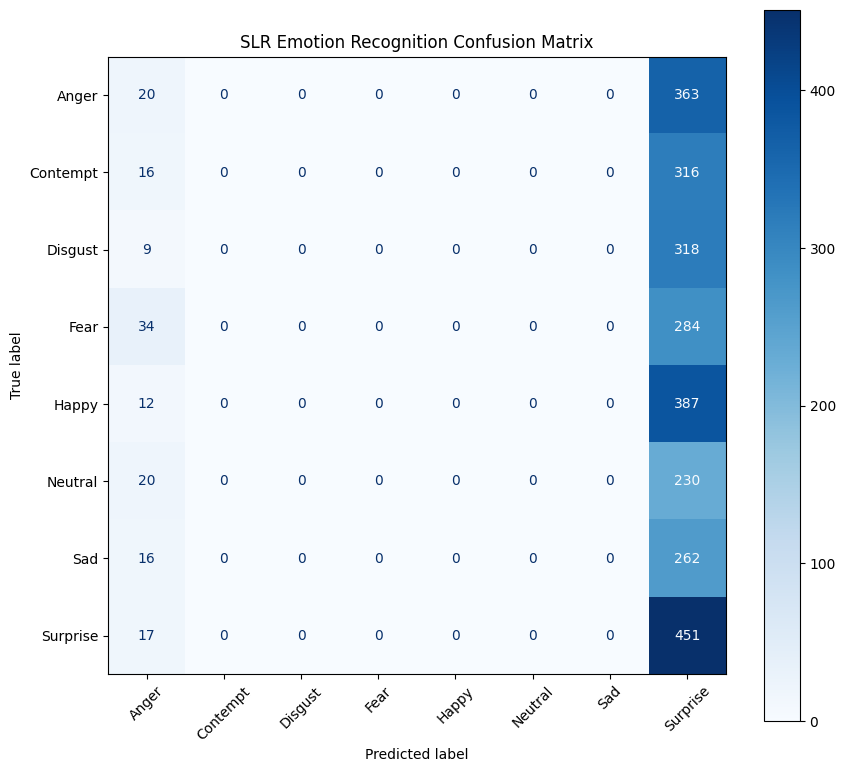

In [50]:
if len(X_test) > 0:

    cm = confusion_matrix(
        y_test,
        test_predictions,
        labels=list(range(NUM_CLASSES))
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    fig, ax = plt.subplots(figsize=(9, 8))

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        xticks_rotation=45
    )

    plt.title("SLR Emotion Recognition Confusion Matrix")
    plt.tight_layout()
    plt.show()

## Cell 27 — Actual vs predicted results

In [51]:
if len(X_test) > 0:

    test_results_df = pd.DataFrame({
        "Feature_X": X_test.flatten(),
        "Actual_ID": y_test,
        "Actual_Emotion": [CLASS_NAMES[i] for i in y_test],
        "Predicted_ID": test_predictions,
        "Predicted_Emotion": [CLASS_NAMES[i] for i in test_predictions]
    })

    test_results_df["Correct"] = (
        test_results_df["Actual_ID"] ==
        test_results_df["Predicted_ID"]
    )

    display(test_results_df.head(30))

,Feature_X,Actual_ID,Actual_Emotion,Predicted_ID,Predicted_Emotion,Correct
0,34.211193,5,Neutral,7,Surprise,False
1,25.988114,1,Contempt,7,Surprise,False
2,54.476471,4,Happy,7,Surprise,False
3,52.505005,4,Happy,7,Surprise,False
4,66.121773,4,Happy,7,Surprise,False
5,40.628454,5,Neutral,7,Surprise,False
6,65.423082,2,Disgust,7,Surprise,False
7,35.385297,4,Happy,7,Surprise,False
8,49.688899,5,Neutral,7,Surprise,False
9,64.103520,7,Surprise,7,Surprise,True


# Visualize Individual Test Predictions

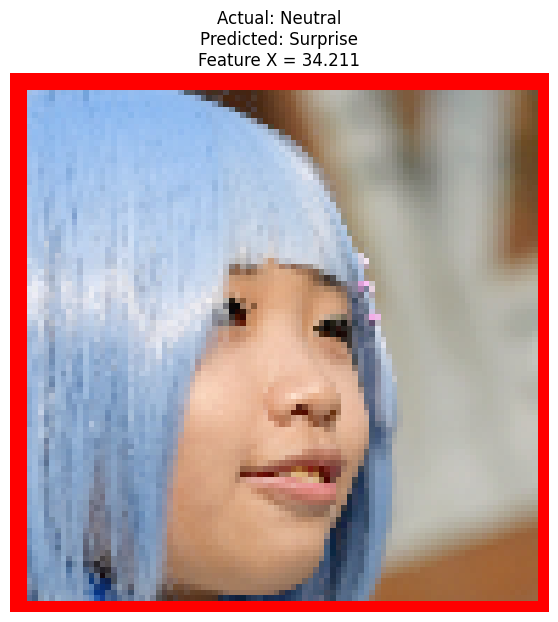

Regression scores:
Surprise       : 0.170353
Disgust        : 0.145168
Happy          : 0.131062
Anger          : 0.127262
Sad            : 0.120171
Contempt       : 0.113757
Fear           : 0.105736
Neutral        : 0.086490


In [52]:
def show_test_prediction(index):

    if len(X_test) == 0:
        print("No test samples available.")
        return

    if index < 0 or index >= len(X_test):
        raise IndexError(
            f"index must be between 0 and {len(X_test)-1}"
        )

    image_path = test_paths[index]

    image = cv2.imread(image_path)

    if image is None:
        print("Unable to read:", image_path)
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    x1, y1, x2, y2 = test_boxes[index]

    actual_id = int(y_test[index])
    actual_name = CLASS_NAMES[actual_id]

    feature = float(X_test[index, 0])

    pred_id, pred_name, scores = predict_emotion(feature)

    # draw box
    cv2.rectangle(
        image_rgb,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

    plt.figure(figsize=(7, 7))
    plt.imshow(image_rgb)
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {pred_name}\n"
        f"Feature X = {feature:.3f}"
    )
    plt.axis("off")
    plt.show()

    print("Regression scores:")

    for class_id, score in sorted(
        scores.items(),
        key=lambda item: item[1],
        reverse=True
    ):
        print(f"{CLASS_NAMES[class_id]:15s}: {score:.6f}")


# Example
if len(X_test) > 0:
    show_test_prediction(0)

## Cell 29 — Show several test predictions

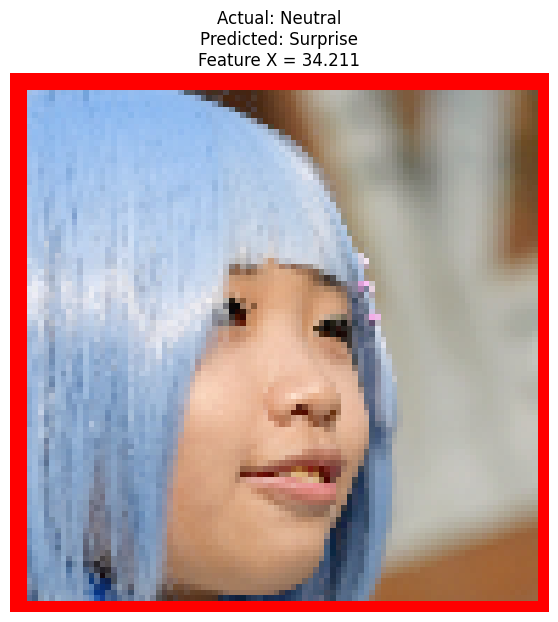

Regression scores:
Surprise       : 0.170353
Disgust        : 0.145168
Happy          : 0.131062
Anger          : 0.127262
Sad            : 0.120171
Contempt       : 0.113757
Fear           : 0.105736
Neutral        : 0.086490


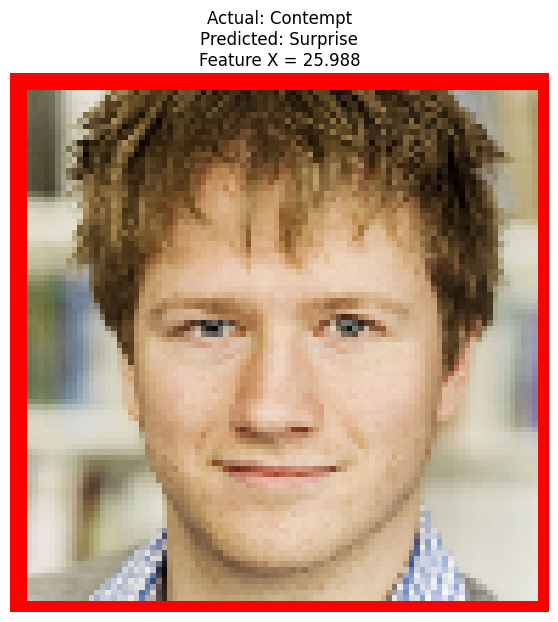

Regression scores:
Surprise       : 0.174145
Disgust        : 0.154850
Happy          : 0.134576
Sad            : 0.125849
Anger          : 0.120713
Contempt       : 0.111719
Fear           : 0.097170
Neutral        : 0.080979


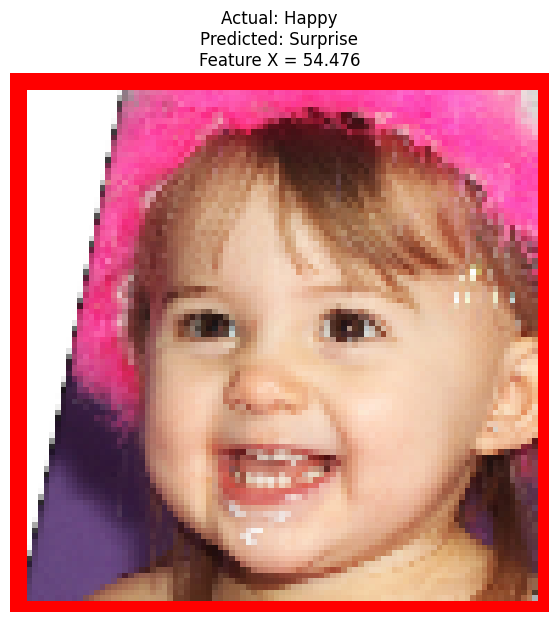

Regression scores:
Surprise       : 0.161008
Anger          : 0.143402
Fear           : 0.126847
Happy          : 0.122402
Disgust        : 0.121308
Contempt       : 0.118780
Sad            : 0.106179
Neutral        : 0.100074


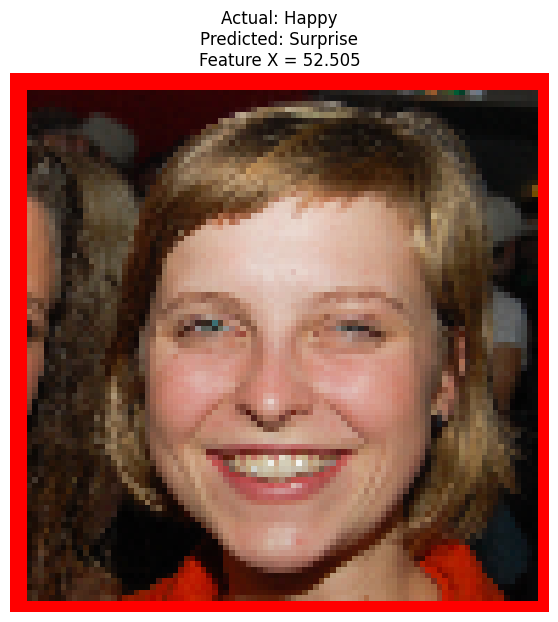

Regression scores:
Surprise       : 0.161917
Anger          : 0.141832
Fear           : 0.124793
Disgust        : 0.123629
Happy          : 0.123245
Contempt       : 0.118292
Sad            : 0.107540
Neutral        : 0.098752


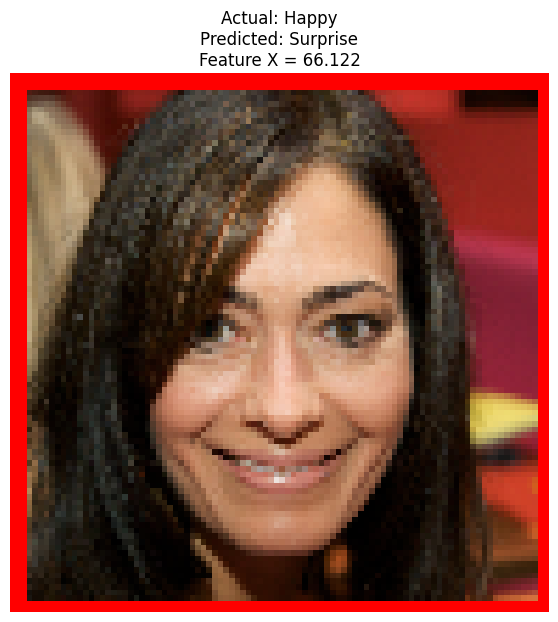

Regression scores:
Surprise       : 0.155637
Anger          : 0.152676
Fear           : 0.138978
Contempt       : 0.121667
Happy          : 0.117426
Neutral        : 0.107879
Disgust        : 0.107597
Sad            : 0.098138


In [53]:
for i in range(min(5, len(X_test))):
    show_test_prediction(i)

# Final Learning Summary

The complete workflow is:

```text
YOLO image
   ↓
YOLO annotation
   ↓
Bounding box
   ↓
Crop face/emotion region
   ↓
Grayscale + resize
   ↓
ONE numerical feature X
   ↓
SLR models
   ↓
y_hat = b0 + b1 X
   ↓
Regression scores
   ↓
argmax
   ↓
Predicted emotion
```

## What students learn

| SLR concept | Emotion experiment |
|---|---|
| \(X\) | One facial-image feature |
| \(y\) | 0/1 one-vs-rest target |
| \(b_0\) | Intercept |
| \(b_1\) | Slope |
| \(\hat y\) | Emotion regression score |
| Residual | \(y-\hat y\) |
| SSE | Sum of squared residuals |
| MSE | Mean squared error |
| \(R^2\) | Regression fit measure |
| Argmax | Select final emotion |
| Accuracy | Overall classification result |
| Confusion matrix | Class-wise errors |

## Important limitation

Simple Linear Regression uses only one predictor. An entire facial expression is therefore compressed to one scalar value, which discards most visual information.

This experiment is useful for learning the mathematics of SLR, but for real emotion recognition, later experiments should move to:

**Logistic Regression → SVM → CNN / YOLO classification**

In [1]:
%pip install numpy pandas pillow matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from pathlib import Path

home = Path.home()

print("Your home folder:", home)
print("\nCommon folders:")

for folder in [
    home / "Downloads",
    home / "Desktop",
    home / "Documents",
    home / "Downloads" / "YOLO_format",
    home / "Desktop" / "YOLO_format"
]:
    print(folder, "->", "FOUND" if folder.exists() else "not found")

Your home folder: /Users/pranathisingaluri

Common folders:
/Users/pranathisingaluri/Downloads -> FOUND
/Users/pranathisingaluri/Desktop -> FOUND
/Users/pranathisingaluri/Documents -> FOUND
/Users/pranathisingaluri/Downloads/YOLO_format -> FOUND
/Users/pranathisingaluri/Desktop/YOLO_format -> not found


In [5]:
DATASET_ROOT = Path.home() / "Downloads" / "YOLO_format"

print("Dataset path:", DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())
print("Folders:", [p.name for p in DATASET_ROOT.iterdir()] 
      if DATASET_ROOT.exists() else "Path not found")

Dataset path: /Users/pranathisingaluri/Downloads/YOLO_format
Dataset exists: True
Folders: ['valid', '.DS_Store', 'test', 'data.yaml', 'train']


In [6]:
EMOTIONS = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

for i, emotion in enumerate(EMOTIONS):
    print(i, "->", emotion)

0 -> Anger
1 -> Contempt
2 -> Disgust
3 -> Fear
4 -> Happy
5 -> Neutral
6 -> Sad
7 -> Surprise


In [7]:
IMAGE_SIZE = (24, 24)

def load_split(split_name):
    image_dir = DATASET_ROOT / split_name / "images"
    label_dir = DATASET_ROOT / split_name / "labels"

    if not image_dir.exists() or not label_dir.exists():
        raise FileNotFoundError(
            f"Could not find images or labels for {split_name}. "
            f"Check the folder structure."
        )

    features = []
    labels = []

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

    for label_file in label_dir.glob("*.txt"):
        image_path = next(
            (
                p for p in image_dir.glob(label_file.stem + ".*")
                if p.suffix.lower() in image_extensions
            ),
            None
        )

        if image_path is None:
            continue

        try:
            image = Image.open(image_path).convert("RGB")
            image_width, image_height = image.size

            for line in label_file.read_text().splitlines():
                values = line.split()

                if len(values) < 5:
                    continue

                class_id = int(float(values[0]))

                if not 0 <= class_id < len(EMOTIONS):
                    continue

                x_center, y_center, box_width, box_height = map(
                    float, values[1:5]
                )

                x1 = int((x_center - box_width / 2) * image_width)
                y1 = int((y_center - box_height / 2) * image_height)
                x2 = int((x_center + box_width / 2) * image_width)
                y2 = int((y_center + box_height / 2) * image_height)

                x1 = max(0, min(x1, image_width - 1))
                y1 = max(0, min(y1, image_height - 1))
                x2 = max(x1 + 1, min(x2, image_width))
                y2 = max(y1 + 1, min(y2, image_height))

                crop = image.crop((x1, y1, x2, y2))
                crop = crop.convert("L").resize(IMAGE_SIZE)

                pixels = np.asarray(crop, dtype=np.float32) / 255.0

                features.append(pixels.flatten())
                labels.append(class_id)

        except (OSError, ValueError, IndexError) as error:
            print(f"Skipping {image_path.name}: {error}")

    return np.asarray(features, dtype=np.float32), np.asarray(labels)


print("Image loader is ready!")

Image loader is ready!


In [12]:
def load_split(split_name, max_images=3000):
    image_dir = DATASET_ROOT / split_name / "images"
    label_dir = DATASET_ROOT / split_name / "labels"

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

    # Build an image lookup once
    image_lookup = {
        p.stem: p
        for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    }

    features = []
    labels = []

    label_files = sorted(label_dir.glob("*.txt"))[:max_images]

    for i, label_file in enumerate(label_files):
        image_path = image_lookup.get(label_file.stem)

        if image_path is None:
            continue

        try:
            with Image.open(image_path) as img:
                image = img.convert("RGB")
                w, h = image.size

                for line in label_file.read_text().splitlines():
                    values = line.split()
                    if len(values) < 5:
                        continue

                    class_id = int(float(values[0]))
                    if not 0 <= class_id < len(EMOTIONS):
                        continue

                    xc, yc, bw, bh = map(float, values[1:5])

                    x1 = max(0, int((xc - bw / 2) * w))
                    y1 = max(0, int((yc - bh / 2) * h))
                    x2 = min(w, int((xc + bw / 2) * w))
                    y2 = min(h, int((yc + bh / 2) * h))

                    if x2 <= x1 or y2 <= y1:
                        continue

                    crop = image.crop((x1, y1, x2, y2))
                    crop = crop.convert("L").resize(IMAGE_SIZE)

                    features.append(
                        np.asarray(crop, dtype=np.float32).flatten() / 255.0
                    )
                    labels.append(class_id)

        except (OSError, ValueError, IndexError):
            continue

        if (i + 1) % 500 == 0:
            print(f"{split_name}: processed {i + 1} label files")

    return np.asarray(features, dtype=np.float32), np.asarray(labels)


print("Faster loader ready!")

Faster loader ready!


In [13]:
X_train, y_train = load_split("train", max_images=3000)
X_test, y_test = load_split("test", max_images=800)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

train: processed 500 label files
train: processed 1000 label files
train: processed 1500 label files
train: processed 2000 label files
train: processed 2500 label files
train: processed 3000 label files
test: processed 500 label files
Training data: (3000, 576)
Test data: (800, 576)


In [14]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Random Forest accuracy:",
      accuracy_score(y_test, rf_predictions))

Random Forest accuracy: 0.455


In [15]:
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(random_state=42, max_iter=3000)
)

svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)

print("SVM accuracy:",
      accuracy_score(y_test, svm_predictions))

SVM accuracy: 0.47125


In [18]:

# Create a small test set for SVM
X_train_small = X_train[:500]
y_train_small = y_train[:500]

X_test_small = X_test[:200]
y_test_small = y_test[:200]

print("Training samples:", len(y_train_small))
print("Testing samples:", len(y_test_small))

Training samples: 500
Testing samples: 200


In [20]:

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Train SVM on the smaller dataset
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(dual=True, max_iter=2000, random_state=42)
)

svm_model.fit(X_train_small, y_train_small)

# Generate predictions
predictions = svm_model.predict(X_test_small)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test_small, predictions)

print("SVM accuracy:", round(svm_accuracy * 100, 2), "%")

SVM accuracy: 43.0 %


In [21]:

print("Random Forest accuracy:", round(rf_accuracy * 100, 2), "%")
print("SVM accuracy:", round(svm_accuracy * 100, 2), "%")

Random Forest accuracy: 37.97 %
SVM accuracy: 43.0 %


In [22]:
# Random Forest predictions on the SAME 200 test samples
rf_predictions_small = rf_model.predict(X_test_small)

# SVM predictions
svm_predictions_small = svm_model.predict(X_test_small)

print("Both models predicted the same test set!")

Both models predicted the same test set!


,Model,Accuracy (%)
0,Random Forest,46.5
1,SVM,43.0


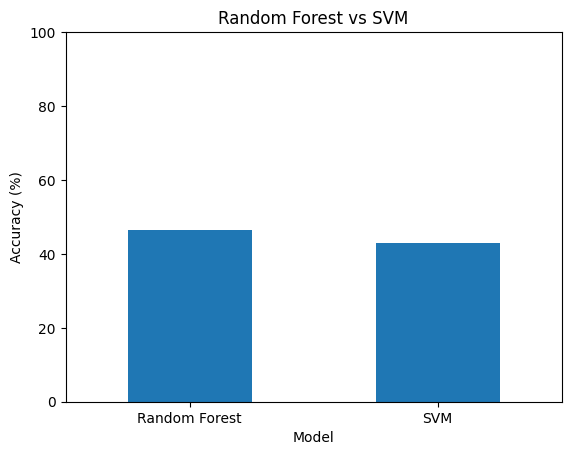

In [23]:
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

rf_accuracy_small = accuracy_score(
    y_test_small, rf_predictions_small
)

svm_accuracy_small = accuracy_score(
    y_test_small, svm_predictions_small
)

results = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy (%)": [
        rf_accuracy_small * 100,
        svm_accuracy_small * 100
    ]
})

display(results.round(2))

results.plot(
    x="Model",
    y="Accuracy (%)",
    kind="bar",
    legend=False,
    ylim=(0, 100),
    title="Random Forest vs SVM"
)

plt.ylabel("Accuracy (%)")
plt.xticks(rotation=0)
plt.show()

In [24]:
from sklearn.metrics import classification_report

print("RANDOM FOREST")
print(classification_report(
    y_test_small,
    rf_predictions_small,
    labels=list(range(8)),
    target_names=EMOTIONS,
    zero_division=0
))

print("SVM")
print(classification_report(
    y_test_small,
    svm_predictions_small,
    labels=list(range(8)),
    target_names=EMOTIONS,
    zero_division=0
))

RANDOM FOREST
              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00        12
    Contempt       0.36      0.14      0.21        28
     Disgust       0.00      0.00      0.00        10
        Fear       0.00      0.00      0.00         3
       Happy       0.50      0.96      0.66        73
     Neutral       0.41      0.43      0.42        37
         Sad       0.00      0.00      0.00        13
    Surprise       0.60      0.12      0.21        24

    accuracy                           0.47       200
   macro avg       0.23      0.21      0.19       200
weighted avg       0.38      0.47      0.37       200

SVM
              precision    recall  f1-score   support

       Anger       0.22      0.17      0.19        12
    Contempt       0.28      0.25      0.26        28
     Disgust       0.00      0.00      0.00        10
        Fear       0.00      0.00      0.00         3
       Happy       0.70      0.77      0.73        73
     N

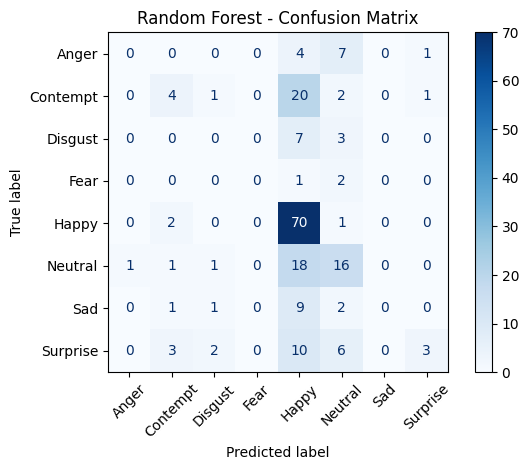

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_small,
    rf_predictions_small,
    labels=list(range(8)),
    display_labels=EMOTIONS,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

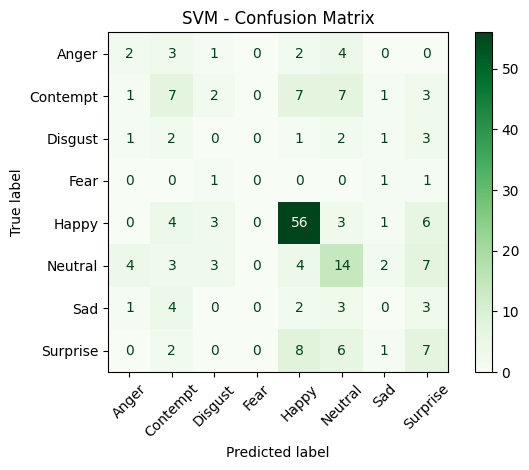

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test_small,
    svm_predictions_small,
    labels=list(range(8)),
    display_labels=EMOTIONS,
    xticks_rotation=45,
    cmap="Greens"
)

plt.title("SVM - Confusion Matrix")
plt.tight_layout()
plt.show()

In [27]:
results.to_csv("random_forest_vs_svm_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [28]:
print("Emotion classes in training data:")

for class_id, emotion in enumerate(EMOTIONS):
    count = int(np.sum(y_train == class_id))
    print(f"{class_id}: {emotion} = {count} samples")

Emotion classes in training data:
0: Anger = 167 samples
1: Contempt = 323 samples
2: Disgust = 225 samples
3: Fear = 51 samples
4: Happy = 1296 samples
5: Neutral = 443 samples
6: Sad = 179 samples
7: Surprise = 316 samples


In [52]:
def predict_emotion(image_path, model):
    image = Image.open(image_path).convert("RGB")

    # Resize to the same size used during training
    image = image.convert("L").resize(IMAGE_SIZE)

    # Convert image to numerical features
    pixels = np.asarray(image, dtype=np.float32) / 255.0
    features = pixels.flatten().reshape(1, -1)

    # Predict
    prediction = model.predict(features)[0]

    return EMOTIONS[prediction]

In [53]:
test_image = next(
    p for p in (DATASET_ROOT / "test" / "images").iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
)

print("Image:", test_image)

Image: /Users/pranathisingaluri/Downloads/YOLO_format/test/images/image0018347.jpg


In [54]:
rf_result = predict_emotion(test_image, rf_model)

print("Random Forest prediction:", rf_result)

Random Forest prediction: Happy


In [55]:
svm_result = predict_emotion(test_image, svm_model)

print("SVM prediction:", svm_result)

SVM prediction: Sad


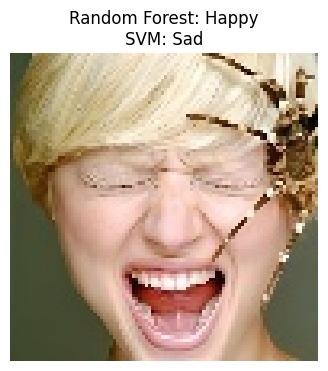

In [56]:
img = Image.open(test_image)

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Random Forest: {rf_result}\n"
    f"SVM: {svm_result}"
)
plt.show()


In [57]:
%pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [58]:
from skimage.feature import hog

print("HOG imported successfully!")

HOG imported successfully!


In [59]:
def extract_hog_features(image_path):
    image = Image.open(image_path).convert("L")
    image = image.resize((48, 48))

    image_array = np.asarray(image, dtype=np.float32) / 255.0

    features = hog(
        image_array,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return features

In [60]:
hog_features = extract_hog_features(test_image)

print("Number of HOG features:", len(hog_features))
print("First 10 features:", hog_features[:10])

Number of HOG features: 900
First 10 features: [0.2999397  0.2999397  0.         0.         0.01146421 0.
 0.09688852 0.01987957 0.13824731 0.20527695]


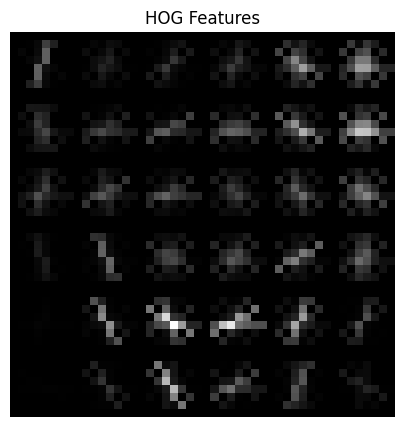

In [61]:
image = Image.open(test_image).convert("L").resize((48, 48))
image_array = np.asarray(image, dtype=np.float32) / 255.0

features, hog_image = hog(
    image_array,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(5, 5))
plt.imshow(hog_image, cmap="gray")
plt.axis("off")
plt.title("HOG Features")
plt.show()

In [62]:
def load_hog_dataset(split_name, max_images=3000):
    image_dir = DATASET_ROOT / split_name / "images"
    label_dir = DATASET_ROOT / split_name / "labels"

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

    image_lookup = {
        p.stem: p
        for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    }

    features = []
    labels = []

    label_files = sorted(label_dir.glob("*.txt"))[:max_images]

    for i, label_file in enumerate(label_files):

        image_path = image_lookup.get(label_file.stem)

        if image_path is None:
            continue

        try:
            image = Image.open(image_path).convert("RGB")
            w, h = image.size

            for line in label_file.read_text().splitlines():

                values = line.split()

                if len(values) < 5:
                    continue

                class_id = int(float(values[0]))

                if not 0 <= class_id < len(EMOTIONS):
                    continue

                xc, yc, bw, bh = map(float, values[1:5])

                x1 = max(0, int((xc - bw / 2) * w))
                y1 = max(0, int((yc - bh / 2) * h))
                x2 = min(w, int((xc + bw / 2) * w))
                y2 = min(h, int((yc + bh / 2) * h))

                if x2 <= x1 or y2 <= y1:
                    continue

                # Crop face
                crop = image.crop((x1, y1, x2, y2))

                # Grayscale + resize
                crop = crop.convert("L").resize((48, 48))

                image_array = np.asarray(
                    crop,
                    dtype=np.float32
                ) / 255.0

                # HOG features
                hog_features = hog(
                    image_array,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    block_norm="L2-Hys"
                )

                features.append(hog_features)
                labels.append(class_id)

        except (OSError, ValueError, IndexError):
            continue

        if (i + 1) % 500 == 0:
            print(f"{split_name}: {i + 1} images processed")

    return np.asarray(features), np.asarray(labels)

In [63]:
X_train_hog, y_train_hog = load_hog_dataset(
    "train",
    max_images=2000
)

print("HOG training shape:", X_train_hog.shape)
print("Training labels:", y_train_hog.shape)

train: 500 images processed
train: 1000 images processed
train: 1500 images processed
train: 2000 images processed
HOG training shape: (2000, 900)
Training labels: (2000,)


In [64]:
X_test_hog, y_test_hog = load_hog_dataset(
    "test",
    max_images=500
)

print("HOG test shape:", X_test_hog.shape)
print("Test labels:", y_test_hog.shape)

test: 500 images processed
HOG test shape: (500, 900)
Test labels: (500,)


In [65]:
rf_hog = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_hog.fit(X_train_hog, y_train_hog)

rf_hog_predictions = rf_hog.predict(X_test_hog)

rf_hog_accuracy = accuracy_score(
    y_test_hog,
    rf_hog_predictions
)

print(
    "Random Forest + HOG accuracy:",
    round(rf_hog_accuracy * 100, 2),
    "%"
)

Random Forest + HOG accuracy: 40.4 %


In [68]:
svm_hog = make_pipeline(
    StandardScaler(),
    LinearSVC(
        max_iter=3000,
        random_state=42,
        class_weight="balanced"
    )
)

svm_hog.fit(X_train_hog, y_train_hog)

svm_hog_predictions = svm_hog.predict(X_test_hog)

svm_hog_accuracy = accuracy_score(
    y_test_hog,
    svm_hog_predictions
)

print(
    "SVM + HOG accuracy:",
    round(svm_hog_accuracy * 100, 2),
    "%"
)

SVM + HOG accuracy: 35.6 %


In [67]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest + HOG",
        "SVM + HOG"
    ],
    "Accuracy (%)": [
        rf_hog_accuracy * 100,
        svm_hog_accuracy * 100
    ]
})

display(final_results.round(2))

,Model,Accuracy (%)
0,Random Forest + HOG,40.4
1,SVM + HOG,35.6


In [69]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVM",
        "Random Forest + HOG",
        "SVM + HOG"
    ],
    "Accuracy (%)": [
        rf_accuracy * 100,
        svm_accuracy * 100,
        rf_hog_accuracy * 100,
        svm_hog_accuracy * 100
    ]
})

display(final_results.round(2))

,Model,Accuracy (%)
0,Random Forest,37.97
1,SVM,43.00
2,Random Forest + HOG,40.40
3,SVM + HOG,35.60


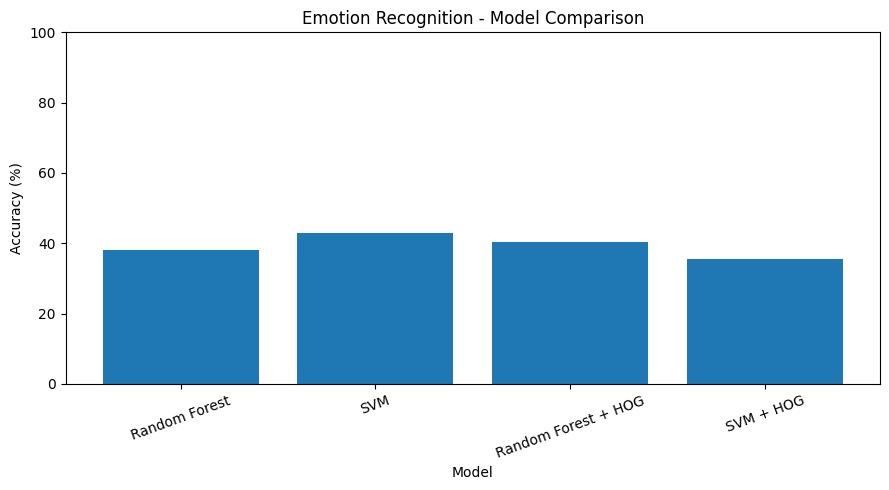

In [70]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results["Model"],
    final_results["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Emotion Recognition - Model Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [71]:
best_model = final_results.loc[
    final_results["Accuracy (%)"].idxmax()
]

print("BEST MODEL:", best_model["Model"])
print("BEST ACCURACY:", round(best_model["Accuracy (%)"], 2), "%")

BEST MODEL: SVM
BEST ACCURACY: 43.0 %


In [72]:
final_results.to_csv(
    "emotion_recognition_model_comparison.csv",
    index=False
)

print("Final comparison saved successfully!")

Final comparison saved successfully!
